# New York Times API

- Author: Brittany An
- Purpose: Query the NYT Archive API for a given month and extract articles mentioning "Cloudflare" within an event window.
- AI usage: Used ChatGPT for debugging details such as Timestamp usage and adding robust error handling



- Note: Very limited news data from NYT regarding the specific Cloudflare event, but will still include it in our dataset for now

API reference: https://developer.nytimes.com/apis

## Year 2019

In [ ]:
# NYT_API_KEY = "" # To rerun the code, use the free API Key offered

In [20]:
import os
import json
import requests
import pandas as pd

In [ ]:
# Fetch one month of NYT Archive docs
def fetch_archive_month(year, month):
    """
    Send a request to the NYT Archive API for a given year/month,
    and return the list of article metadata objects ("docs")
    """
    url = f"https://api.nytimes.com/svc/archive/v1/{year}/{month}.json"
    r = requests.get(url, params={"api-key": NYT_API_KEY}, timeout=120)

    # Helpful error messages (common issues: 401 unauthorized, 429 rate limit)
    if r.status_code == 401:
        raise RuntimeError("NYT API returned 401 Unauthorized. Check NYT_API_KEY.")
    if r.status_code == 429:
        raise RuntimeError("NYT API returned 429 Too Many Requests. Try waiting and rerunning.")

    r.raise_for_status()
    # avoid None.get("docs") AttributeError
    return (r.json().get("response") or {}).get("docs") or []

In [ ]:
# Extract Cloudflare mentions within an event window
def extract_cloudflare_articles(docs: list, start_utc: pd.Timestamp, end_utc: pd.Timestamp):
    """
    Filter month docs by:
    (i) publication time within start_utc and end_utc window
    (ii) "cloudflare" or "cloud flare" mentioned in headline/snippet/lead/url
    Returns a DataFrame.
    """
    rows = []

    for d in docs:
        pub = pd.to_datetime(d.get("pub_date"), utc=True, errors="coerce")
        # make sure publication_date can compare and is within the selected window
        if pd.isna(pub) or not (start_utc <= pub < end_utc):
            continue

        headline = (d.get("headline") or {}).get("main", "") or ""
        snippet  = d.get("snippet", "") or d.get("abstract", "") or ""
        lead     = d.get("lead_paragraph", "") or ""
        url      = d.get("web_url", "") or ""

        # lowercase for case-insensitive search
        text = f"{headline} {snippet} {lead} {url}".lower()

        if ("cloudflare" not in text) and ("cloud flare" not in text):
            continue

        rows.append({
            "pub_datetime_utc": pub,
            "headline": headline,
            "snippet_or_abstract": snippet,
            "lead_paragraph": lead,
            "web_url": url,
            "section": d.get("section_name", "") or "",
            "byline": (d.get("byline") or {}).get("original", "") or "",
        })

    df = pd.DataFrame(rows).sort_values("pub_datetime_utc").reset_index(drop=True)
    return df

In [28]:
# Event window selection
start_utc = pd.Timestamp("2019-07-01T00:00:00Z")
end_utc   = pd.Timestamp("2019-07-05T00:00:00Z")

# Could extend as needed
# event = pd.Timestamp("2019-07-02T00:00:00Z")
# start_utc = event - pd.Timedelta(days=14)
# end_utc   = event + pd.Timedelta(days=15)


docs = fetch_archive_month(2019, 7)
df = extract_cloudflare_articles(docs, start_utc, end_utc)
df.to_csv("nyt_cloudflare_2019-07-02.csv", index=False)

print("saved:", len(df), "rows")

saved: 1 rows


In [18]:
df

,pub_datetime_utc,headline,snippet_or_abstract,lead_paragraph,web_url,section,byline
0,2019-07-03 00:42:03+00:00,"A Failure Here, Damaged Fiber There and a Day ...",Cloudflare and Google dealt with issues that a...,"When a website won’t load, many internet users...",https://www.nytimes.com/2019/07/02/business/cl...,Business Day,By David Yaffe-Bellany


## Year 2025 

In [30]:
# Event window selection for year 2025
start_utc = pd.Timestamp("2025-11-17T00:00:00Z")
end_utc   = pd.Timestamp("2025-11-21T00:00:00Z")

docs = fetch_archive_month(2025, 11)
df = extract_cloudflare_articles(docs, start_utc, end_utc)
df.to_csv("nyt_cloudflare_2025-11-18.csv", index=False)

print("saved:", len(df), "rows")

saved: 1 rows


In [32]:
df

,pub_datetime_utc,headline,snippet_or_abstract,lead_paragraph,web_url,section,byline
0,2025-11-18 12:16:11+00:00,Cloudflare Says It Has Resolved Outage That Di...,"Services from Cloudflare, a software company, ...",,https://www.nytimes.com/2025/11/18/business/cl...,Business,By Victor Mather


# New York Times API2_FULL

- Author : Brittany An
- Purpose: Query the NYT article search API using keyword filter for all 'Cloudflare' relevant news used for later event filter starting from 2009(company founded date)
- AI used for API understanding, debugging, and robustness checks such as avoding duplicates

- Note: need to cut windows due to pagination limits just in case of over result limites (not a issue here, but still processed by year)

API reference: https://developer.nytimes.com/docs/articlesearch-product/1/overview

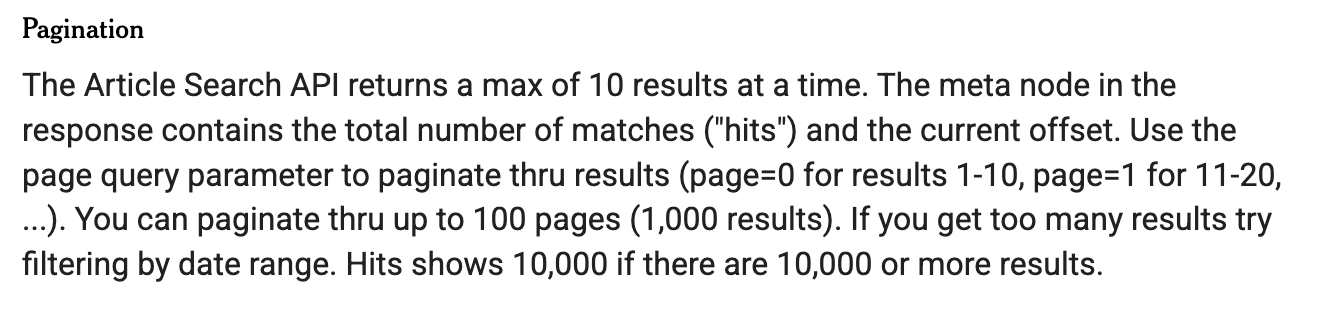

In [ ]:
# NYT_API_KEY = "Fmh19bhWAPW7ieQTzh8k2P0OLPj3qxLMGfgRdVCbcGAf47T6"

In [82]:
# NYT_API_KEY = "" # input the free API key here

In [84]:
import os
import time
import math
import requests
import pandas as pd
from datetime import datetime

In [ ]:
# fetch by year to avoid pagination/results limits
# filter_query used to restrict article types, such as news articles

def fetch_year(q, year, filter_query=None):
    """
    Fetch NYT news for a given calendar year

    Inputs:
        q(str): Full-text search query ("cloudflare")
        year(int): Calendar year to fetch
        filter_query(str or None): Field-based filter query using Lucene syntax to restrict
        results by structured metadata fields (e.g. 'typeOfMaterials:News')

    Returns a list of NYT "docs" objects(raw JSON dicts) for one year.
    Note each element is one article metadata record.
    """
    begin = f"{year}0101"
    end   = f"{year}1231"
    if year == END_YEAR:
        end = END_CUTOFF # cut off only for 2026

    docs_all = []
    page = 0

    # pagination limit 100
    while page < 100:
        params = {
            "api-key": NYT_API_KEY,
            "q": q,
            "begin_date": begin,
            "end_date": end,
            "page": page,
            "sort": "oldest",
        }
        if filter_query: # only when filter_query is not None
            params["fq"] = filter_query

        r = requests.get(base_url, params=params, timeout=60)
        if r.status_code == 429:
            # # basic rate limit handling
            time.sleep(2)
            continue

        r.raise_for_status()

        data = r.json()
        docs = (data.get("response") or {}).get("docs") or []

        if not docs: # no docs returned for this page
            # stop paging(reached end or no matches)
            break

        docs_all.extend(docs)
        page += 1
        # only move to the next page when success to avoid skipping pages due to 429
        time.sleep(0.3)

    return docs_all

In [ ]:
def to_df(docs):
    """
    Convert a list of NYT news "docs"(raw JSON dicts) into a pandas DataFrame

    Input:
        docs: List of dict. Each dict contains metadata for one article

    Returns: A dataframe each row per article with selected fields
    """
    rows = []
    for d in docs:
        rows.append({
            "_id": d.get("_id", ""), # unique for each article
            "pub_date": d.get("pub_date", ""),
            "headline": (d.get("headline") or {}).get("main", "") or "",
            "web_url": d.get("web_url", "") or "",
            "snippet": d.get("snippet", "") or d.get("abstract", "") or "",
            # in case no snippet, keep abstract

            "section": d.get("section_name", "") or "",
            "byline": (d.get("byline") or {}).get("original", "") or "", # author info
            "type_of_material": d.get("type_of_material", "") or "",
            "source": d.get("source", "") or "",
        })

    df = pd.DataFrame(rows)

    if "pub_date" in df.columns:
        # in case no news for the year, rows will be empty
        df["pub_date"] = pd.to_datetime(df["pub_date"], utc=True, errors="coerce")

    return df

In [49]:
base_url = "https://api.nytimes.com/svc/search/v2/articlesearch.json"

In [ ]:
# fix end data cutoff to 2026-02-02
START_YEAR = 2009
END_YEAR   = 2026
END_CUTOFF = "20260202"
# FILTER_QUERY = 'typeOfMaterials:News'
q = 'cloudflare'  # case-insensitive

In [ ]:
all_docs = []

for y in range(START_YEAR, END_YEAR + 1):
    docs_y = fetch_year(q, y, filter_query=FILTER_QUERY)
    all_docs.extend(docs_y)
    print("year", y, "docs", len(docs_y))

df = to_df(all_docs)
df = df.sort_values("pub_date").drop_duplicates("_id").reset_index(drop=True)
# avoid duplicates, drop articles with same unique id

out_file = f"nyt_cloudflare_{START_YEAR}0101_{END_CUTOFF}.csv"
df.to_csv(out_file, index=False)
print("saved:", len(df), "rows in ", out_file)

year 2009 docs 5
year 2010 docs 0
year 2011 docs 0
year 2012 docs 3
year 2013 docs 10
year 2014 docs 10
year 2015 docs 8
year 2016 docs 2
year 2017 docs 8
year 2018 docs 3
year 2019 docs 13
year 2020 docs 5
year 2021 docs 6
year 2022 docs 3
year 2023 docs 3
year 2024 docs 7
year 2025 docs 8
year 2026 docs 28
saved: 122 rows in  nyt_cloudflare_20090101_20260202.csv


## basic processing

- initial processing to filter actual Cloudflare related news

In [95]:
import os
import pandas as pd
base_path = "/Users/brittanyan/Desktop/2026Winter/MACS30122 Python Data Management/project"
raw_file_path = os.path.join(base_path,"nyt_cloudflare_20090101_20260202.csv")
df_raw = pd.read_csv(raw_file_path)

In [97]:
df_raw.head()

,_id,pub_date,headline,web_url,snippet,section,byline,type_of_material,source
0,nyt://article/26a70ca4-d10f-57d6-818d-cf55592b...,2009-08-13 17:19:05+00:00,TD2 Barely Holding On,https://topics.blogs.nytimes.com/2009/08/13/td...,.,Times Topics,By Brian D. McNoldy,News,The New York Times
1,nyt://article/652261c8-c8a5-55cb-a6fc-64101722...,2009-08-14 20:21:21+00:00,"TD2 Dissipates, Easterly Wave Getting Organized",https://topics.blogs.nytimes.com/2009/08/14/td...,.,Times Topics,By Brian D. McNoldy,News,The New York Times
2,nyt://article/4e732e0e-7d06-5913-b72a-83c93a73...,2009-08-17 21:13:04+00:00,"Ana, Bill, and Claudette Made for a Full Weekend",https://topics.blogs.nytimes.com/2009/08/17/an...,.,Times Topics,By Brian McNoldy,News,The New York Times
3,nyt://article/73adede5-856d-591a-8d03-9054d95f...,2009-08-19 19:14:00+00:00,Bill Strengthens to a Category 4 Hurricane,https://topics.blogs.nytimes.com/2009/08/19/bi...,.,Times Topics,By Brian D. McNoldy,News,The New York Times
4,nyt://article/b2fec01f-d4b3-51ef-a944-2e49e62c...,2009-08-21 21:10:50+00:00,Bill Heads Northwest Between Bermuda and U.S.,https://topics.blogs.nytimes.com/2009/08/21/bi...,.,Times Topics,By Brian D. McNoldy,News,The New York Times


In [99]:
df_raw.columns

Index(['_id', 'pub_date', 'headline', 'web_url', 'snippet', 'section',
       'byline', 'type_of_material', 'source'],
      dtype='object')

In [101]:
df_raw.type_of_material.value_counts()

type_of_material
News    122
Name: count, dtype: int64

In [103]:
# build a text field from columns for rough filtering
text = (
    df[["headline", "snippet", "web_url"]]
    .fillna("")
    .astype(str)
    .agg(" ".join, axis=1)
    .str.lower()
)

# keep only rows where the word "cloudflare" appears (not just "cloud")
mask = text.str.contains(r"\bcloud\s*flare\b", regex=True)

df2 = df.loc[mask].copy()
df2["pub_date"] = pd.to_datetime(df2["pub_date"], utc=True, errors="coerce")

out_file2 = f"NEW_nyt_cloudflare_{START_YEAR}0101_{END_CUTOFF}.csv"
df2 = df2.sort_values("pub_date").drop_duplicates("_id").reset_index(drop=True)
df2.to_csv(out_file2, index=False)

print("raw file:", len(df), "rows")
print("new file:", len(df2), "rows", out_file2)

raw file: 122 rows
new file: 10 rows NEW_nyt_cloudflare_20090101_20260202.csv


In [105]:
new_path = os.path.join(base_path,out_file2)

In [107]:
df_new = pd.read_csv(new_path)
df_new

,_id,pub_date,headline,web_url,snippet,section,byline,type_of_material,source
0,nyt://article/1a2bf51d-ca3a-50a2-b17a-0fc63111...,2012-02-17 17:54:32+00:00,Preparing for DDoS Attacks or Just Groundhog Day,https://bits.blogs.nytimes.com/2012/02/17/prep...,A number of companies help Web sites fight bas...,Technology,By Nicole Perlroth,News,The New York Times
1,nyt://article/cb404a07-5753-5f28-83a0-d4f25989...,2015-09-14 00:57:10+00:00,Baidu and CloudFlare Boost Users Over China’s ...,https://www.nytimes.com/2015/09/14/business/pa...,"The Chinese search giant Baidu and CloudFlare,...",Technology,By Paul Mozur,News,The New York Times
2,nyt://article/32e94921-1ba6-5f11-81b1-28ecae17...,2017-08-11 11:00:15+00:00,Matthew Prince of Cloudflare on the Dangers of...,https://www.nytimes.com/2017/08/11/business/co...,The chief executive of a cybersecurity firm sa...,Business,By Adam Bryant,News,The New York Times
3,nyt://article/ddcc81da-d52c-57cc-a5a2-2e2c549c...,2019-07-03 00:42:03+00:00,"A Failure Here, Damaged Fiber There and a Day ...",https://www.nytimes.com/2019/07/02/business/cl...,Cloudflare and Google dealt with issues that a...,Business,By David Yaffe-Bellany,News,The New York Times
4,nyt://article/049ea2fb-eaec-5b32-8313-6dcea654...,2019-08-04 18:01:29+00:00,"‘Shut the Site Down,’ Says the Creator of 8cha...",https://www.nytimes.com/2019/08/04/technology/...,The site is a venue for extremists to test out...,Technology,By Kevin Roose,News,The New York Times
5,nyt://article/99fc864c-e158-5670-9736-2ea7641a...,2019-08-05 14:24:13+00:00,Why Banning 8chan Was So Hard for Cloudflare: ...,https://www.nytimes.com/2019/08/05/technology/...,"8chan, the anonymous message board used by the...",Technology,By Kevin Roose,News,The New York Times
6,nyt://article/6094fa8d-1e99-5f52-b122-115bfb5a...,2024-04-09 14:42:25+00:00,Internet Traffic Dipped as Viewers Took in the...,https://www.nytimes.com/2024/04/09/business/in...,Internet traffic dropped by 40 percent or more...,Business,By Jenny Gross,News,The New York Times
7,nyt://article/e687c4db-d296-5f9a-96e9-a4469171...,2025-07-01 10:00:13+00:00,Cloudflare Introduces Default Blocking of A.I....,https://www.nytimes.com/2025/07/01/technology/...,The tech company’s customers can automatically...,Technology,By Natallie Rocha,News,The New York Times
8,nyt://article/5433efe5-6c47-5f84-b080-88a9806a...,2025-08-01 11:00:09+00:00,Age-Gating the Internet + Cloudflare Takes On ...,https://www.nytimes.com/2025/08/01/podcasts/ha...,"“Frankly, if they’re going to behave like hack...",Podcasts,"By Kevin Roose, Casey Newton, Rachel Cohn, Whi...",News,The New York Times
9,nyt://article/627eb1f3-c42e-51b6-8f88-8fdf9795...,2025-11-18 12:16:11+00:00,Cloudflare Says It Has Resolved Outage That Di...,https://www.nytimes.com/2025/11/18/business/cl...,"Services from Cloudflare, a software company, ...",Business,By Victor Mather,News,The New York Times


# The Guardian API

- Author: Brittany An
- Purpose: Query the Guardian Open Platform API for "Cloudflare" within a specified date range, then filter results to keep only relevant outage-related articles (remove briefing/liveblog noise).
- AI usage: ChatGPT was used to debug noisy news returns and refine filtering rules (e.g., exclude non-article types like liveblog/briefing) and generating outage_terms.

API reference: https://open-platform.theguardian.com/documentation/

Note: Very limited news data from The Guardian as well regarding the specific Cloudflare event, but will still include it in our dataset for now

In [114]:
# GUARDIAN_KEY = "" # To rerun the code, use the free API Key offered
BASE = "https://content.guardianapis.com/search"

In [116]:
import time
import requests
import pandas as pd

In [118]:
def guardian_search_all(q, from_date, to_date,
                        page_size=200, max_pages=50,
                        sleep_s=1.05):
    """
    Pull all search results from the Guardian API within selected time window,
    paginating until exhausted or max_pages reached.
    maximum 200 result per page, sleep for 1.05 after each page to avoid reaching rate limit
    """
    output = [] # store all results across pages list[dict]
    page = 1

    while page <= max_pages:
        params = {
            "api-key": GUARDIAN_KEY,
            "q": q, # free-text query
            "from-date": from_date,
            "to-date": to_date,
            "use-date": "published", # use publication date to select dates
            "order-by": "newest",
            "page-size": page_size,
            "page": page, # current page
            "show-fields": "trailText,bodyText", # include extra text fields
        }

        r = requests.get(BASE, params=params, timeout=60) # wait for max 60s
        r.raise_for_status() # raise an error for non-200 responses
        data = r.json() # parsed JSON to Python dict

        response = data.get("response") or {} # "response" key from data dict
        # use `or {}` to avoid later None.get() error

        results = response.get("results") or [] # results for this page (list of dicts)
        output.extend(results) # merge this page into the global list

        pages = response.get("pages") or page # return total pages or current page
        # Stop if reached the last page, or API returns an empty page
        if page >= pages or len(results) == 0:
            break

        page += 1
        time.sleep(sleep_s)

    return output

In [120]:
def to_rows_cloudflare_outage(results):
    """
    Keep only news that are likely about a Cloudflare outage:
      (1) type must be 'article' (exclude liveblog/briefing)
      (2) title must contain 'cloudflare'
      (3) full text must contain outage-related terms

    Input: results(list[dict]): raw result dicts returned by API
    Returns rows as filtered records
    """

    # Keywords that suggest the content is describing a service outage incident
    outage_terms = [
        "outage", "downtime", "disruption", "glitch",
        "service disruption", "service interruption",
        "error", "error messages", "went down",
        "is down", "was down", "taken offline",]

    rows = [] # list[dict]  Filtered relevant records

    # Iterate over raw API results
    # Each item is a dict representing one content item
    for item in results:
        # filter by content type and skip non-article items
        typ = (item.get("type") or "").lower()
        if typ != "article":
            continue

        title = item.get("webTitle") or ""
        title_l = title.lower()

        # title must explicitly mention cloudflare
        if "cloudflare" not in title_l:
            continue

        # extract additional text fields if available
        fields = item.get("fields") or {}
        trail = fields.get("trailText") or "" # short summary
        body = fields.get("bodyText") or "" # full text (if provided)

        # use title/trail/body for matching
        text = f"{title} {trail} {body}".lower()

        # Require at least one outage-related term in the text
        if not any(t in text for t in outage_terms):
            continue

        rows.append({
            "pub_date": item.get("webPublicationDate") or "",
            "title": title,
            "section": item.get("sectionName") or "",
            "type": item.get("type") or "",
            "web_url": item.get("webUrl") or "",
            "trailText": trail,
            "bodyText": body,
        })

    return rows

## Year 2019(No results)

In [155]:
from_date = "2019-07-01"
to_date   = "2019-07-04"
q = 'cloudflare OR "cloud flare"'
results = guardian_search_all(q, from_date, to_date,
                              page_size=200, max_pages=50)


# event-focused filtering
# rows = to_rows_cloudflare_outage(results)

# df = pd.DataFrame(rows)
# df = df.sort_values("pub_date")

# out_path1 = "guardian_cloudflare_outage_2019-07-01_2019-07-04.csv"
# df.to_csv(out_path, index=False)

# print("raw results:", len(results))
# print("filtered news:", len(df))

In [153]:
results

[]

## Year 2025

In [157]:
from_date = "2025-11-17"
to_date   = "2025-11-20"
q = 'cloudflare OR "cloud flare"'
results = guardian_search_all(q, from_date, to_date,
                              page_size=200, max_pages=50)


# event-focused filtering
rows = to_rows_cloudflare_outage(results)

df = pd.DataFrame(rows)
df = df.sort_values("pub_date")

out_path2 = "guardian_cloudflare_outage_2025-11-17_2025-1-20.csv"
df.to_csv(out_path2, index=False)

print("raw results:", len(results))
print("filtered news:", len(df))

raw results: 6
filtered news: 2


In [143]:
df2 = pd.read_csv(out_path2)
df2

,pub_date,title,section,type,web_url,trailText,bodyText
0,2025-11-18T15:11:51Z,Cloudflare outage causes error messages across...,Technology,article,https://www.theguardian.com/technology/2025/no...,US company that defends millions of websites a...,A key piece of the internet’s usually hidden i...
1,2025-11-18T15:23:42Z,What is Cloudflare – and why did its outage ta...,Technology,article,https://www.theguardian.com/technology/2025/no...,"Bet365, League of Legends, Sage, YouTube and G...",The internet infrastructure provider Cloudflar...


# The Guardian API2_FULL

- Apply to all years starting from 2009

In [124]:
# GUARDIAN_KEY = "" # To rerun the code, use the free API Key offered
BASE = "https://content.guardianapis.com/search"

In [126]:
import time
import requests
import pandas as pd

In [128]:
def guardian_search_all(q, from_date, to_date,
                        page_size=200, max_pages=50,
                        sleep_s=1.05):
    """
    Pull all search results from the Guardian API within selected time window,
    paginating until exhausted or max_pages reached.
    maximum 200 result per page, sleep for 1.05 after each page to avoid reaching rate limit
    """
    output = [] # store all results across pages list[dict]
    page = 1

    while page <= max_pages:
        params = {
            "api-key": GUARDIAN_KEY,
            "q": q, # free-text query
            "from-date": from_date,
            "to-date": to_date,
            "use-date": "published", # use publication date to select dates
            "order-by": "newest",
            "page-size": page_size,
            "page": page, # current page
            "show-fields": "trailText,bodyText", # include extra text fields
        }

        r = requests.get(BASE, params=params, timeout=60) # wait for max 60s
        r.raise_for_status() # raise an error for non-200 responses
        data = r.json() # parsed JSON to Python dict

        response = data.get("response") or {} # "response" key from data dict
        # use `or {}` to avoid later None.get() error

        results = response.get("results") or [] # results for this page (list of dicts)
        output.extend(results) # merge this page into the global list

        pages = response.get("pages") or page # return total pages or current page
        # Stop if reached the last page, or API returns an empty page
        if page >= pages or len(results) == 0:
            break

        page += 1
        time.sleep(sleep_s)

    return output

In [130]:
def to_rows_cloudflare_outage(results):
    """
    Keep only news that are likely about a Cloudflare outage:
      (1) type must be 'article' (exclude liveblog/briefing)
      (2) title must contain 'cloudflare'
      (3) full text must contain outage-related terms

    Input: results(list[dict]): raw result dicts returned by API
    Returns rows as filtered records
    """

    # Keywords that suggest the content is describing a service outage incident
    outage_terms = [
        "outage", "downtime", "disruption", "glitch",
        "service disruption", "service interruption",
        "error", "error messages", "went down",
        "is down", "was down", "taken offline",]

    rows = [] # list[dict]  Filtered relevant records

    # Iterate over raw API results
    # Each item is a dict representing one content item
    for item in results:
        # filter by content type and skip non-article items
        typ = (item.get("type") or "").lower()
        if typ != "article":
            continue

        title = item.get("webTitle") or ""
        title_l = title.lower()

        # title must explicitly mention cloudflare
        if "cloudflare" not in title_l:
            continue

        # extract additional text fields if available
        fields = item.get("fields") or {}
        trail = fields.get("trailText") or "" # short summary
        body = fields.get("bodyText") or "" # full text (if provided)

        # use title/trail/body for matching
        text = f"{title} {trail} {body}".lower()

        # Require at least one outage-related term in the text
        if not any(t in text for t in outage_terms):
            continue

        rows.append({
            "pub_date": item.get("webPublicationDate") or "",
            "title": title,
            "section": item.get("sectionName") or "",
            "type": item.get("type") or "",
            "web_url": item.get("webUrl") or "",
            "trailText": trail,
            "bodyText": body,
        })

    return rows

In [132]:
from_date = "2009-01-01"
to_date   = "2026-02-02"
q = 'cloudflare OR "cloud flare"'
results = guardian_search_all(q, from_date, to_date,
                              page_size=200, max_pages=50)


# event-focused filtering
rows = to_rows_cloudflare_outage(results)

df = pd.DataFrame(rows)
df = df.sort_values("pub_date")

out_path3 = "guardian_cloudflare_outage_2ALL.csv"
df.to_csv(out_path3, index=False)

print("raw results:", len(results))
print("filtered news:", len(df))

raw results: 103
filtered news: 9


# GDELT gkg News Data 

Code for initial processing directly downloaded GDELT GKG data to extract Cloudflare-related news coverage within predefined event windows.

data source: https://data.gdeltproject.org/gkg/index.html

- Author: Brittany An
- Purpose: Process directly downloaded GDELT GKG daily CSV files and extract all news records mentioning "Cloudflare" within the 2019-07-01 to 2019-07-04 and 2025-11-17 to 2025-11-20 event window.
- AI usage: ChatGPT helped with debugging loading gkg.csv file(sep='\t')

In [3]:
import os
import re
import pandas as pd

# Base directory containing unzipped GDELT GKG CSV files
base_dir = "/Users/brittanyan/Desktop/2026Winter/MACS30122 Python Data Management/project/GDELT"

# cloudflare / cloud flare case insensitive
pattern = re.compile(r"\bcloud\s*flare\b|\bcloudflare\b", flags=re.IGNORECASE)

## Year 2019

In [9]:
# GKG files covering the selected Cloudflare event window
files = ["20190701.gkg.csv",
         "20190702.gkg.csv",
         "20190703.gkg.csv",
         "20190704.gkg.csv",]

dfs = []
for file in files:
    path = os.path.join(base_dir, file)
    df = pd.read_csv(path, sep="\t", dtype=str)

    # keep if cloudflare/cloud flare appeared in a row
    row_text = df.fillna("").astype(str).agg(" ".join, axis=1)
    # Replace NaN with empty strings, convert all columns to string,
    # then concatenate all column values in each row into one long text string
    # (axis=1 means row-wise aggregation)

    mask = row_text.str.contains(pattern, regex=True) # boolean mask(True if contains pattern)
    dfs.append(df.loc[mask]) # keep rows mentions cloudflare

df_all = pd.concat(dfs, ignore_index=True)

print("Total matched rows:", len(df_all))

out_path1 = os.path.join(base_dir, "gdelt_20190701_20190704_cloudflare_mentions.csv")
df_all.to_csv(out_path1, index=False)
print("Saved:", out_path1)

Total matched rows: 38
Saved: /Users/brittanyan/Desktop/2026Winter/MACS30122 Python Data Management/project/GDELT/gdelt_20190701_20190704_cloudflare_mentions.csv


In [11]:
df_2019 = pd.read_csv(out_path1)
df_2019.head()

,DATE,NUMARTS,COUNTS,THEMES,LOCATIONS,PERSONS,ORGANIZATIONS,TONE,CAMEOEVENTIDS,SOURCES,SOURCEURLS
0,20190701,1,NaN,NaN,1#Germany#GM#GM#51.5#10.5#GM;1#Italy#IT#IT#42....,NaN,wordpress,"1.92307692307692,3.2967032967033,1.37362637362...",NaN,namehero.com,https://www.namehero.com/startup/you-probably-...
1,20190701,1,NaN,EPU_ECONOMY_HISTORIC;TAX_FNCACT;TAX_FNCACT_GUI...,1#Lithuania#LH#LH#56#24#LH;1#United Kingdom#UK...,bluehost bluehost;hostinger hostinger;godaddy ...,google;microsoft office;wordpress;endurance in...,"3.99673735725938,5.573681348559,1.576943991299...",NaN,techradar.com,https://www.techradar.com/best/best-website-ho...
2,20190702,1,AFFECT#2000#popular websites#1#United States#U...,AFFECT;TAX_ETHNICITY;TAX_ETHNICITY_AMERICAN;EP...,1#United States#US#US#39.828175#-98.5795#US,NaN,NaN,"-1.43540669856459,3.82775119617225,5.263157894...",NaN,sky.com,https://news.sky.com/story/cloudflare-down-tho...
3,20190702,1,NaN,TAX_FNCACT;TAX_FNCACT_CEO;TAX_FNCACT_PRINCE;ME...,"3#Miami, Florida, United States#US#USFL#25.774...",los angeles,twitter,"-1.27226463104326,1.78117048346056,3.053435114...",856516283,crn.com,https://www.crn.com/news/security/-major-cloud...
4,20190702,1,NaN,NaN,"2#New York, United States#US#USNY#42.1497#-74....",NaN,gerrit de vynck bloomberg cloudflare inc;cloud...,"-2.29885057471264,1.14942528735632,3.448275862...",NaN,datacenterknowledge.com,https://www.datacenterknowledge.com:443/uptime...


## Year 2025

In [15]:
# GKG files covering the selected Cloudflare event window
files = ["20251117.gkg.csv",
         "20251118.gkg.csv",
         "20251119.gkg.csv",
         "20251120.gkg.csv"]

dfs = []
for file in files:
    path = os.path.join(base_dir, file)
    df = pd.read_csv(path, sep="\t", dtype=str)

    # keep if cloudflare/cloud flare appeared in a row
    mask = df.fillna("").astype(str).agg(" ".join, axis=1).str.contains(pattern, regex=True)
    dfs.append(df.loc[mask])

df_all = pd.concat(dfs, ignore_index=True)

print("Total matched rows:", len(df_all))

out_path2 = os.path.join(base_dir, "gdelt_20251117_20251120_cloudflare_mentions.csv")
df_all.to_csv(out_path2, index=False)
print("Saved:", out_path2)

Total matched rows: 620
Saved: /Users/brittanyan/Desktop/2026Winter/MACS30122 Python Data Management/project/GDELT/gdelt_20251117_20251120_cloudflare_mentions.csv


In [17]:
df_2025 = pd.read_csv(out_path2)
df_2025.head()

,DATE,NUMARTS,COUNTS,THEMES,LOCATIONS,PERSONS,ORGANIZATIONS,TONE,CAMEOEVENTIDS,SOURCES,SOURCEURLS
0,20251117,1,NaN,TAX_FNCACT;TAX_FNCACT_INVESTOR;TAX_FNCACT_ANAL...,1#Canada#CA#CA#60#-96#CA,thomas j seifert;stifel nicolaus,larson financial group;securities exchange com...,"1.43487858719647,1.76600441501104,0.3311258278...",NaN,themarketsdaily.com,https://www.themarketsdaily.com/2025/11/17/wes...
1,20251117,1,NaN,TAX_FNCACT;TAX_FNCACT_PRINCE;TAX_FNCACT_CEO;TA...,"4#Lisbon, Lisboa, Portugal#PO#PO14#38.7167#-9....",NaN,google,"0.241545893719807,3.98550724637681,3.743961352...","1274566256,1274566296,1274566297,1274566298,12...",indiatimes.com,https://timesofindia.indiatimes.com/technology...
2,20251118,1,NaN,AFFECT;TAX_ETHNICITY;TAX_ETHNICITY_AMERICAN;WB...,1#United States#US#US#39.828175#-98.5795#US,NaN,reuters;akamai;delivery network;amazon web ser...,"-0.269541778975741,3.50404312668464,3.77358490...",NaN,siasat.com,https://www.siasat.com/issues-with-cloudflare-...
3,20251118,1,NaN,NaN,"2#New Jersey, United States#US#USNJ#40.314#-74...",NaN,moody;microsoft,"-3.47826086956522,1.73913043478261,5.217391304...",NaN,ktar.com,https://ktar.com/national-news/cloudflare-outa...
4,20251118,1,NaN,AFFECT;MEDIA_SOCIAL;TAX_FNCACT;TAX_FNCACT_OFFI...,"4#Thunder Bay, Ontario, Canada#CA#CA08#48.4#-8...",NaN,technology local news,"-3.84615384615385,3.14685314685315,6.993006993...",NaN,netnewsledger.com,https://www.netnewsledger.com/2025/11/18/cloud...
